# Logistic Regression from Scratch

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
class LogisticRegressionScratch:
    #Defining learning rate and number of iterations (It represents the steps and how many tries we use until finding the 
    #function that most closely represents the distribution)
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights= None
        self.bias = 0
        self.cost_history = []
        
    #Sigmoid converts the linear combination of input features into a probability score    
    def sigmoid(self,z):
        """Sigmoid activation function"""
        return 1/(1 + np.exp(-z))
    
    #Log Loss Function (cross-entropy) - Quantifies a machine learning model's prediction error
    def cost(self, h,y):
        m = len(y)
        return -(1/m)*np.sum(y*np.log(h)+(1-y)*np.log(1-h))
    
    #Train model using gradient descent 
    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        
        for _ in range(self.iterations):
            z = np.dot(X, self.weights) +self.bias
            h = self.sigmoid(z)
            
            dw = (1/m)*np.dot(X.T, (h-y))
            db = (1/m)*np.sum(h-y)
            
            self.weights -= self.lr*dw
            self.bias -= self.lr*db
            
            self.cost_history.append(self.cost(h,y))
            
    #Make predictions
    def predict(self, X):
        return(self.sigmoid(np.dot(X, self.weights) + self.bias) >= 0.5).astype(int)    

In [10]:
#Generate synthetic dataset 
np.random.seed(42)
X=np.random.rand(200,2)*10
y=(X[:, 0] + X[:, 1] > 10).astype(int)
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data for faster convergence
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Train our logistic regression model
model = LogisticRegressionScratch(learning_rate=0.1, iterations=1000)
model.fit(X_train, y_train)

# Evaluate accuracy
predictions = model.predict(X_test)
accuracy = np.mean(predictions == y_test)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.93


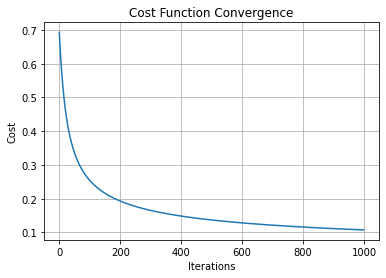

In [12]:
plt.plot(model.cost_history)
plt.title("Cost Function Convergence")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()